In [1]:
from typing import List,TypedDict,Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

e:\Machine Learning and Data Science\Advanced-RAGS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("documents/Company_Policies.pdf").load()
    + PyPDFLoader("documents/Company_Profile.pdf").load()
    + PyPDFLoader("documents/Product_and_Pricing.pdf").load()
)

### Chunking

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=200,chunk_overlap=50).split_documents(docs)

In [4]:
len(chunks)

46

### Embeddings and Retriever

In [5]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vector_stores = FAISS.from_documents(chunks,embeddings)

In [6]:
retriever = vector_stores.as_retriever(search_type = 'similarity',search_kwargs={"k":1})

In [7]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

## State

In [8]:
class State(TypedDict):

    question: str


    docs: List[Document]
    context: str
    answer: str
    route: Literal["no_retriever", "single_retrieval", "multi_retrieval"]

### Route Decision

In [9]:
class RouteDecision(BaseModel):
    route: Literal["no_retriever", "single_retrieval", "multi_retrieval"] = Field(
        ...,
        description="Routing strategy for answering the question."
    )

route_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a routing decision system.\n"
            "Return JSON that matches this schema:\n"
            "{{'route': 'no_retriever' | 'single_retrieval' | 'multi_retrieval'}}\n\n"
            "Guidelines:\n"
            "- no_retriever → for general knowledge, definitions, simple explanations.\n"
            "- single_retrieval → for factual queries needing one lookup.\n"
            "- multi_retrieval → for complex, multi-hop, comparison, or reasoning questions.\n"
            "- If unsure, choose single_retrieval."
        ),
        (
            "human", "Question: {question}"
        ),
    ]
)

route_llm = route_prompt | llm.with_structured_output(RouteDecision)


def decide_route(state: State):
    out = route_llm.invoke({"question":state['question']})

    return {"route":out.route}

In [10]:
def generate(state: State):
    out = llm.invoke(state['question'])

    return {'answer': out.content}

In [11]:
def retrieval(state: State):
    
    docs = retriever.invoke(state['question'])

    return {'docs':docs}



In [12]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG Assistant\n"
            "Answer the user question using only the provided context"
        ),
        (
            "human",
            "Question:\n{question}\n"
            "Context:\n{context}"
        ),
    ]
)

def single_step_generate(state: State):

    context = " ".join(d.page_content for d in state['docs'])

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state['question'],
            context = context
        )
    )

    return {'answer':out.content,"context":context}


In [13]:
def multi_retrieval(state: State):
    return {'answer': 'multi retrieval needed'}

In [15]:
def route_after_decision(state: State):
    if state['route'] == "no_retriever":
        return "no_retriever"
    if state['route'] == "multi_retrieval":
        return "multi_retrieval"
    
    return "single_retrieval"

## State

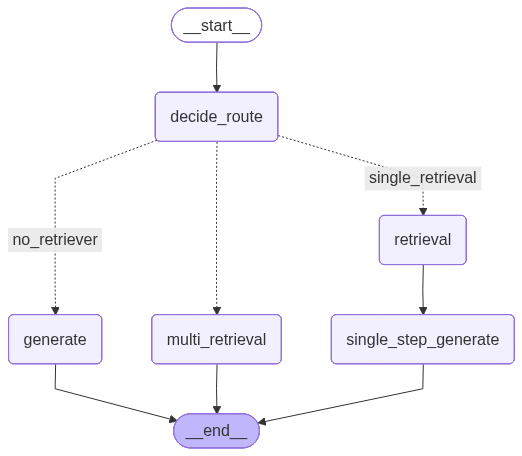

In [16]:
graph = StateGraph(State)

graph.add_node("decide_route",decide_route)
graph.add_node("generate",generate)
graph.add_node("retrieval",retrieval)
graph.add_node("single_step_generate",single_step_generate)
graph.add_node("multi_retrieval",multi_retrieval)


graph.add_edge(START,"decide_route")
graph.add_conditional_edges(
    "decide_route",
    route_after_decision,
    {"no_retriever":"generate","multi_retrieval":"multi_retrieval","single_retrieval":"retrieval"}
)

graph.add_edge("generate",END)
graph.add_edge("multi_retrieval",END)

graph.add_edge("retrieval","single_step_generate")
graph.add_edge("single_step_generate",END)

app = graph.compile()
app


In [17]:
result = app.invoke({'question':"what is 10 multiple 9 ?"})

In [18]:
print(result['answer'])

10 multiplied by 9 is **90**.


In [19]:
print(result['route'])

no_retriever


In [20]:
result = app.invoke({'question':"who is the ceo of NexaAI?"})

In [21]:
print(result['answer'])

The provided context states that Aarav Mehta founded NexaAI, but it does not mention who the CEO is.


In [22]:
print(result['route'])

single_retrieval


In [23]:
print(result['context'])

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
